In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# define training hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

INPUT_DIM = 784       # 28x28 flattened MNIST image
HIDDEN_DIM = 400      # hidden layer size
LATENT_DIM = 20       # size of the latent space (z)
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3

print(f"Using device: {device}")

Using device: cuda


In [3]:
# Download and loading the MNIST dataset, normalize pixel values to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Total training samples: {len(train_dataset)}")

Total training samples: 60000


In [4]:
# Define the Encoder: compresses input image into mean (mu) and log variance (log_var)
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.fc1    = nn.Linear(INPUT_DIM, HIDDEN_DIM)
        self.fc_mu  = nn.Linear(HIDDEN_DIM, LATENT_DIM)   # outputs mean (μ)
        self.fc_var = nn.Linear(HIDDEN_DIM, LATENT_DIM)   # outputs log variance log(σ²)
        self.relu   = nn.ReLU()

    def forward(self, x):
        h      = self.relu(self.fc1(x))
        mu     = self.fc_mu(h)
        log_var = self.fc_var(h)
        return mu, log_var

In [5]:
# Apply the reparameterization trick to sample z = mu + eps * sigma (keeps gradients flowing)
def reparameterize(mu, log_var):
    std = torch.exp(0.5 * log_var)       # σ = exp(0.5 * log(σ²))
    eps = torch.randn_like(std)          # random noise ~ N(0, I)
    z   = mu + eps * std                 # sampled latent vector z
    return z

In [6]:
# Define the Decoder: reconstructs the image from the sampled latent vector z
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc1    = nn.Linear(LATENT_DIM, HIDDEN_DIM)
        self.fc_out = nn.Linear(HIDDEN_DIM, INPUT_DIM)
        self.relu   = nn.ReLU()
        self.tanh   = nn.Tanh()           # output range matches normalized input [-1, 1]

    def forward(self, z):
        h    = self.relu(self.fc1(z))
        x_reconstructed = self.tanh(self.fc_out(h))
        return x_reconstructed

In [7]:
# Combine Encoder, reparameterization, and Decoder into a single VAE class
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        x   = x.view(-1, INPUT_DIM)              # flatten the image
        mu, log_var = self.encoder(x)             # encode to latent params
        z   = reparameterize(mu, log_var)         # sample z
        x_reconstructed = self.decoder(z)         # decode back to image
        return x_reconstructed, mu, log_var

model = VAE().to(device)
print(model)

VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=784, out_features=400, bias=True)
    (fc_mu): Linear(in_features=400, out_features=20, bias=True)
    (fc_var): Linear(in_features=400, out_features=20, bias=True)
    (relu): ReLU()
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=20, out_features=400, bias=True)
    (fc_out): Linear(in_features=400, out_features=784, bias=True)
    (relu): ReLU()
    (tanh): Tanh()
  )
)


In [8]:
# Define VAE loss = Reconstruction Loss (MSE) + KL Divergence Loss
def vae_loss(x_reconstructed, x_original, mu, log_var):
    x_original = x_original.view(-1, INPUT_DIM)

    # Reconstruction loss: how close is the output to the input
    recon_loss = nn.functional.mse_loss(x_reconstructed, x_original, reduction='sum')

    # KL divergence: how close is the learned distribution to standard normal N(0,1)
    # Formula: -0.5 * sum(1 + log(σ²) - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return recon_loss, kl_loss

In [9]:
# Train the VAE for all epochs, printing reconstruction and KL loss at each epoch
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_recon_loss = 0
    total_kl_loss    = 0

    for batch_idx, (images, _) in enumerate(train_loader):
        images = images.to(device)

        # Forward pass
        x_reconstructed, mu, log_var = model(images)

        # Compute losses
        recon_loss, kl_loss = vae_loss(x_reconstructed, images, mu, log_var)
        total_loss = recon_loss + kl_loss

        # Backprop and update weights
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        total_recon_loss += recon_loss.item()
        total_kl_loss    += kl_loss.item()

    # Print average losses for this epoch
    avg_recon = total_recon_loss / len(train_loader.dataset)
    avg_kl    = total_kl_loss    / len(train_loader.dataset)
    print(f"Epoch [{epoch}/{EPOCHS}]  Reconstruction Loss: {avg_recon:.4f}  |  KL Divergence Loss: {avg_kl:.4f}")

Epoch [1/10]  Reconstruction Loss: 98.6586  |  KL Divergence Loss: 22.3418
Epoch [2/10]  Reconstruction Loss: 55.3261  |  KL Divergence Loss: 26.8013
Epoch [3/10]  Reconstruction Loss: 49.5217  |  KL Divergence Loss: 27.4239
Epoch [4/10]  Reconstruction Loss: 46.6429  |  KL Divergence Loss: 27.6747
Epoch [5/10]  Reconstruction Loss: 44.8662  |  KL Divergence Loss: 27.8300
Epoch [6/10]  Reconstruction Loss: 43.6623  |  KL Divergence Loss: 27.9326
Epoch [7/10]  Reconstruction Loss: 42.6652  |  KL Divergence Loss: 28.0072
Epoch [8/10]  Reconstruction Loss: 41.9391  |  KL Divergence Loss: 28.0623
Epoch [9/10]  Reconstruction Loss: 41.3466  |  KL Divergence Loss: 28.0829
Epoch [10/10]  Reconstruction Loss: 40.7850  |  KL Divergence Loss: 28.1382


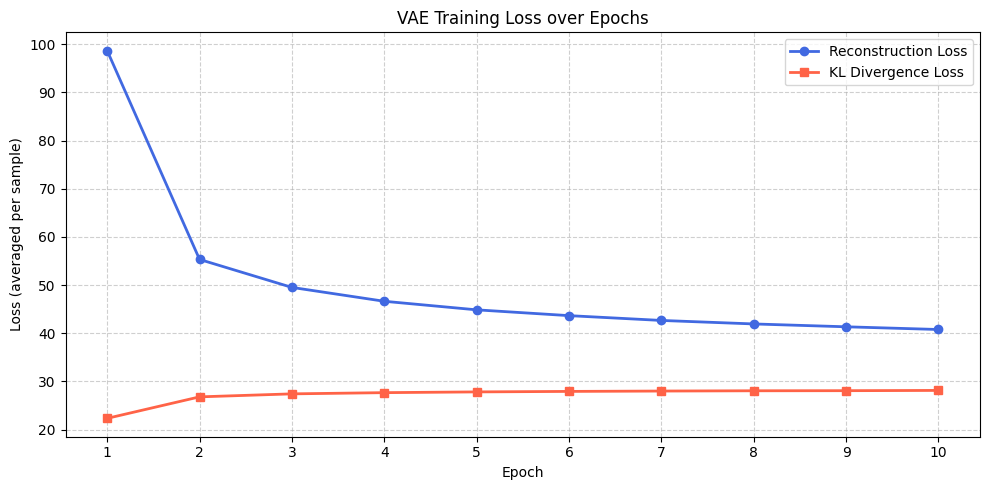

In [11]:
# Plot Reconstruction Loss and KL Divergence Loss across all epochs
epochs = list(range(1, 11))
recon_losses = [98.6586, 55.3261, 49.5217, 46.6429, 44.8662, 43.6623, 42.6652, 41.9391, 41.3466, 40.7850]
kl_losses    = [22.3418, 26.8013, 27.4239, 27.6747, 27.8300, 27.9326, 28.0072, 28.0623, 28.0829, 28.1382]

plt.figure(figsize=(10, 5))
plt.plot(epochs, recon_losses, marker='o', color='royalblue', linewidth=2, label='Reconstruction Loss')
plt.plot(epochs, kl_losses,    marker='s', color='tomato',    linewidth=2, label='KL Divergence Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (averaged per sample)')
plt.title('VAE Training Loss over Epochs')
plt.xticks(epochs)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

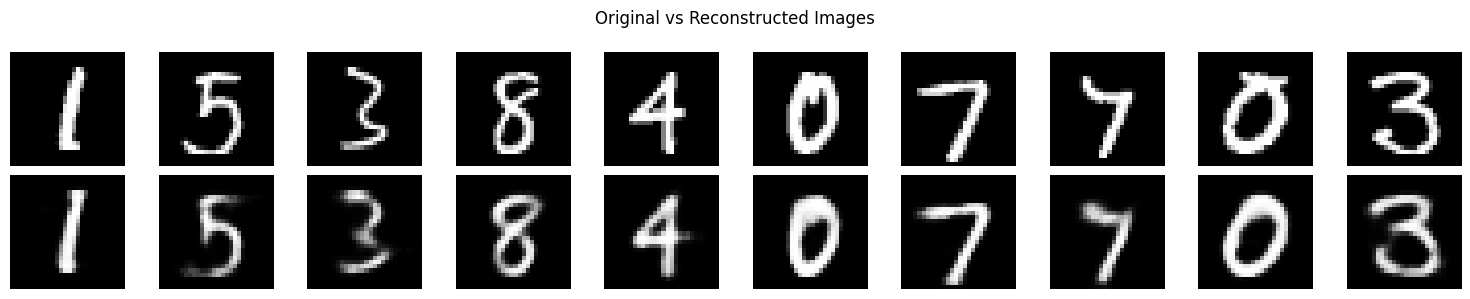

In [10]:
# Visualize original vs reconstructed images to check how well the VAE learned
model.eval()
with torch.no_grad():
    sample_images, _ = next(iter(train_loader))
    sample_images = sample_images.to(device)
    reconstructed, _, _ = model(sample_images)
    reconstructed = reconstructed.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(sample_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
plt.suptitle("Original vs Reconstructed Images")
plt.tight_layout()
plt.show()

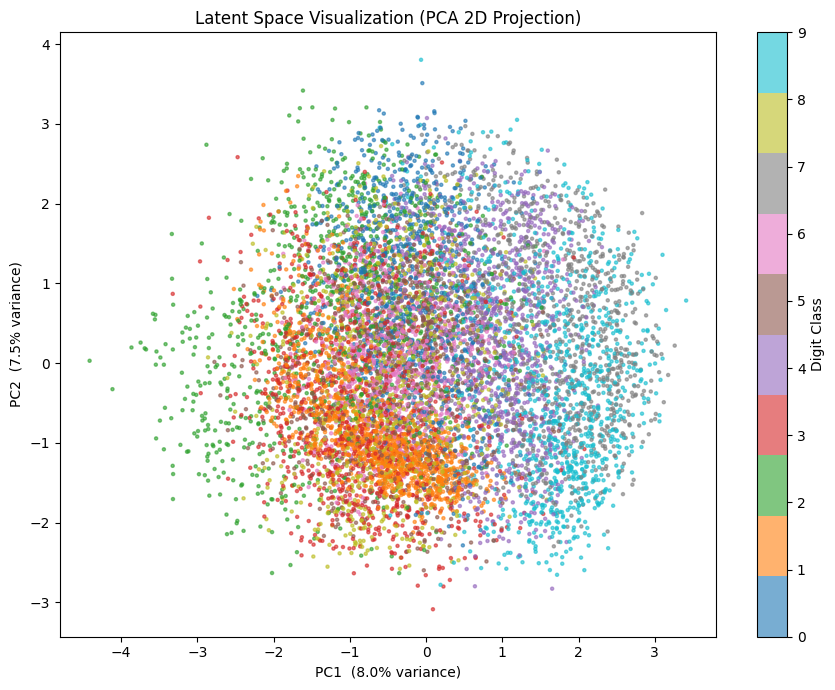

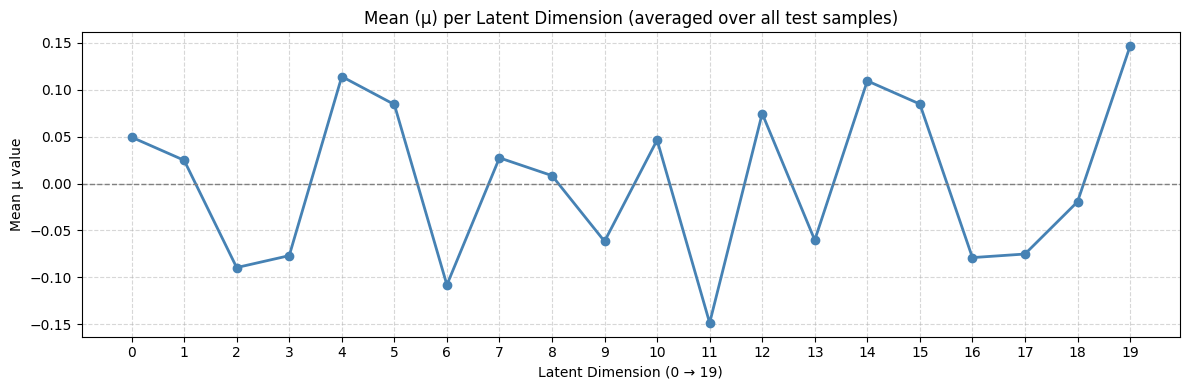

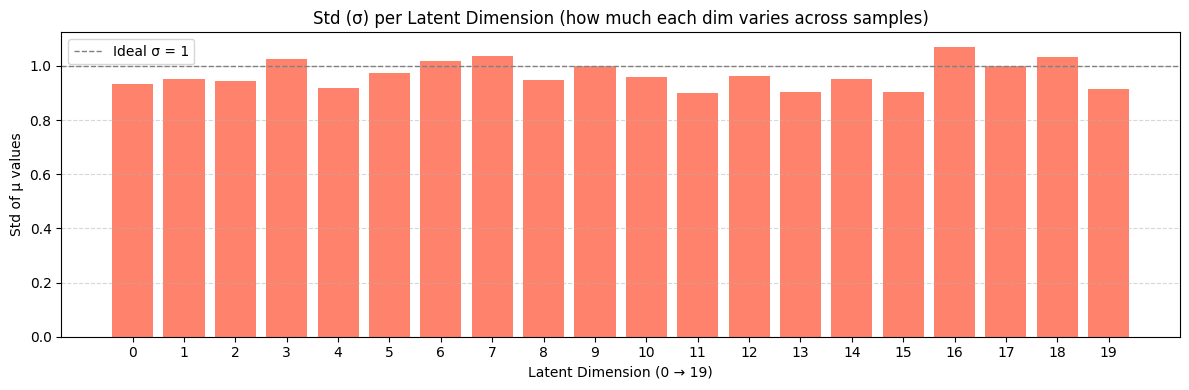


Dim        Mean μ      Std σ
----------------------------
0          0.0494     0.9342
1          0.0248     0.9528
2         -0.0896     0.9431
3         -0.0769     1.0249
4          0.1141     0.9177
5          0.0843     0.9753
6         -0.1081     1.0162
7          0.0274     1.0382
8          0.0084     0.9464
9         -0.0617     0.9984
10         0.0463     0.9575
11        -0.1486     0.8987
12         0.0746     0.9633
13        -0.0603     0.9035
14         0.1094     0.9500
15         0.0847     0.9021
16        -0.0790     1.0703
17        -0.0752     0.9997
18        -0.0195     1.0333
19         0.1465     0.9147


In [12]:
# Encode all test images into latent space and visualize using 2D PCA projection
from sklearn.decomposition import PCA
import numpy as np

test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Collect all latent means (mu) and their digit labels
model.eval()
all_mu     = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, log_var = model.encoder(images.view(-1, INPUT_DIM))
        all_mu.append(mu.cpu().numpy())
        all_labels.append(labels.numpy())

all_mu     = np.concatenate(all_mu,     axis=0)   # shape: (10000, 20)
all_labels = np.concatenate(all_labels, axis=0)   # shape: (10000,)

# ── Plot 1: 2D PCA of the latent space (colored by digit class) ──────────────
pca    = PCA(n_components=2)
mu_2d  = pca.fit_transform(all_mu)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(mu_2d[:, 0], mu_2d[:, 1],
                      c=all_labels, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(scatter, ticks=range(10), label='Digit Class')
plt.title('Latent Space Visualization (PCA 2D Projection)')
plt.xlabel(f'PC1  ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2  ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

# ── Plot 2: Mean (μ) values per latent dimension ─────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(all_mu.mean(axis=0), marker='o', color='steelblue', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title('Mean (μ) per Latent Dimension (averaged over all test samples)')
plt.xlabel('Latent Dimension (0 → 19)')
plt.ylabel('Mean μ value')
plt.xticks(range(LATENT_DIM))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ── Plot 3: Std (σ) values per latent dimension ───────────────────────────────
plt.figure(figsize=(12, 4))
plt.bar(range(LATENT_DIM), all_mu.std(axis=0), color='tomato', alpha=0.8)
plt.axhline(1, color='gray', linestyle='--', linewidth=1, label='Ideal σ = 1')
plt.title('Std (σ) per Latent Dimension (how much each dim varies across samples)')
plt.xlabel('Latent Dimension (0 → 19)')
plt.ylabel('Std of μ values')
plt.xticks(range(LATENT_DIM))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

# ── Print summary table ───────────────────────────────────────────────────────
print(f"\n{'Dim':<6} {'Mean μ':>10} {'Std σ':>10}")
print("-" * 28)
for i in range(LATENT_DIM):
    print(f"{i:<6} {all_mu[:, i].mean():>10.4f} {all_mu[:, i].std():>10.4f}")